#Detección de Focos de Calor (NASA FIRMS) — Bolivia
## Modelos Supervisados: AdaBoost, Gradient Boosting, SVM y Comparación General ("AB Testing" de Modelos)

**Dataset:** Focos de calor detectados por satélite (NASA FIRMS) en Bolivia (~600,000 registros).

**Tareas de este notebook:**
1. **Regresión** → predecir `frp_log` (potencia radiativa del fuego, transformada log).
2. **Clasificación** → predecir `daynight_num` (1 = Día, 0 = Noche).

Para cada tarea se entrenan y comparan:
- Modelos "clásicos" (lineales, KNN, Naive Bayes, árboles, Random Forest)
- **AdaBoost** (con curva de aprendizaje por iteración)
- **Gradient Boosting** (sklearn, XGBoost, LightGBM, CatBoost — con curva de error por árbol)
- **SVM** (SVR / SVC, con comparación de kernel y de C)
- Una **tabla comparativa final ("AB Testing")** con todos los modelos entrenados, para justificar cuál es el mejor.

> Nota metodológica: con ~600k filas, SVM y KNN son computacionalmente costosos (escalan mal con n). Para esos dos modelos se entrena sobre una **muestra aleatoria estratificada** del dataset, indicada explícitamente en el código. Esto es una práctica estándar en la industria cuando se trabaja con estos algoritmos a gran escala, y se documenta como tal en el informe.


## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

!pip install catboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# --- Modelos: Regresión ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
)
from sklearn.svm import SVR

# --- Modelos: Clasificación ---
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC

# --- Boosting de librerías externas ---
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# --- Métricas ---
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

RANDOM_STATE = 42


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


## 2. Carga del dataset

Ajusta `RUTA_CSV` a la ubicación real de tu archivo (el CSV con los ~600,000 focos de calor).

In [38]:
RUTA_CSV = "dataset_incendios_listo_modelos.csv"  # <-- CAMBIA ESTO por la ruta real de tu dataset

df = pd.read_csv(RUTA_CSV)

print("Dimensiones:", df.shape)
df.head()


Dimensiones: (671786, 17)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,confidence_num,frp_log,daynight_num
0,-14.19033,-61.34149,303.75,0.43,0.38,01/01/2025,529,N20,VIIRS,n,2,282.14,1.56,N,50.0,0.940007,0
1,-14.19383,-61.34204,300.92,0.43,0.38,01/01/2025,529,N20,VIIRS,n,2,281.91,0.75,N,50.0,0.559616,0
2,-13.76781,-66.84778,317.80,0.45,0.39,01/01/2025,530,N20,VIIRS,n,2,269.06,2.89,N,50.0,1.358409,0
3,-13.76852,-66.84359,311.95,0.45,0.39,01/01/2025,530,N20,VIIRS,n,2,268.09,2.89,N,50.0,1.358409,0
4,-15.05342,-61.26105,300.75,0.44,0.39,01/01/2025,530,N20,VIIRS,n,2,268.36,1.29,N,50.0,0.828552,0


In [40]:
df.info()
print()
print("Valores nulos por columna:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671786 entries, 0 to 671785
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   latitude        671786 non-null  float64
 1   longitude       671786 non-null  float64
 2   brightness      671786 non-null  float64
 3   scan            671786 non-null  float64
 4   track           671786 non-null  float64
 5   acq_date        671786 non-null  object 
 6   acq_time        671786 non-null  int64  
 7   satellite       671786 non-null  object 
 8   instrument      671786 non-null  object 
 9   confidence      671786 non-null  object 
 10  version         671786 non-null  object 
 11  bright_t31      671786 non-null  float64
 12  frp             671786 non-null  float64
 13  daynight        671786 non-null  object 
 14  confidence_num  671786 non-null  float64
 15  frp_log         671786 non-null  float64
 16  daynight_num    671786 non-null  int64  
dtypes: float64

### Limpieza mínima
Nos aseguramos de que las columnas objetivo y las variables de entrada no tengan nulos, y que los tipos de dato sean correctos.

In [41]:
cols_necesarias = [
    'brightness', 'bright_t31', 'scan', 'track', 'confidence_num',
    'frp_log', 'daynight_num'
]
df = df.dropna(subset=cols_necesarias).copy()
print("Dimensiones tras limpieza:", df.shape)


Dimensiones tras limpieza: (671786, 17)


## 3. Funciones de evaluación reutilizables

Una función para regresión y otra para clasificación. Todos los modelos se evalúan exactamente igual para que la comparación final sea justa.

In [42]:
def evaluate_regression(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {
        "Modelo": model_name, "MAE": mae, "MSE": mse,
        "RMSE": rmse, "R2": r2, "MAPE (%)": mape
    }


def evaluate_classification(y_true, y_pred, y_proba, model_name):
    return {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }


---
## PARTE A — REGRESIÓN: predecir `frp_log`

**X:** `brightness, bright_t31, scan, track, confidence_num`
**y:** `frp_log` (recuerda: `np.expm1(prediccion)` para volver a Megavatios reales)


### A.1 Preparación de datos

In [43]:
features_reg = ['brightness', 'bright_t31', 'scan', 'track', 'confidence_num']
target_reg = 'frp_log'

X_reg = df[features_reg]
y_reg = df[target_reg]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# Escalado (necesario para modelos lineales, SVR; no afecta a árboles/boosting)
scaler_reg = StandardScaler()
Xr_train_s = scaler_reg.fit_transform(Xr_train)
Xr_test_s = scaler_reg.transform(Xr_test)

print("Train:", Xr_train.shape, " Test:", Xr_test.shape)


Train: (537428, 5)  Test: (134358, 5)


### A.2 Comparación general ("AB Testing") — todos los modelos de regresión

Se entrena cada modelo con la configuración estándar de sklearn (parámetros por defecto o razonables) para tener una **línea base comparativa justa**. Luego, en las secciones A.3, A.4 y A.5 se profundiza en AdaBoost, Gradient Boosting y SVR (los modelos asignados a este trabajo).

> **KNN y SVR** se entrenan sobre una muestra de 30,000 filas por costo computacional (ver nota metodológica en la portada).

In [44]:
SAMPLE_SIZE = 30_000
idx_sample = Xr_train.sample(n=min(SAMPLE_SIZE, len(Xr_train)), random_state=RANDOM_STATE).index
Xr_train_small = Xr_train.loc[idx_sample]
yr_train_small = yr_train.loc[idx_sample]
Xr_train_small_s = scaler_reg.transform(Xr_train_small)

resultados_reg = []

# --- Lineales ---
lin = LinearRegression().fit(Xr_train_s, yr_train)
resultados_reg.append(evaluate_regression(yr_test, lin.predict(Xr_test_s), "Regresión Lineal"))

ridge = Ridge(alpha=1.0).fit(Xr_train_s, yr_train)
resultados_reg.append(evaluate_regression(yr_test, ridge.predict(Xr_test_s), "Ridge"))

lasso = Lasso(alpha=0.01).fit(Xr_train_s, yr_train)
resultados_reg.append(evaluate_regression(yr_test, lasso.predict(Xr_test_s), "Lasso"))

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5).fit(Xr_train_s, yr_train)
resultados_reg.append(evaluate_regression(yr_test, elastic.predict(Xr_test_s), "ElasticNet"))

# --- Polinomial (grado 2) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
Xr_train_poly = poly.fit_transform(Xr_train_s)
Xr_test_poly = poly.transform(Xr_test_s)
poly_model = LinearRegression().fit(Xr_train_poly, yr_train)
resultados_reg.append(evaluate_regression(yr_test, poly_model.predict(Xr_test_poly), "Polinomial (g2)"))

# --- KNN (muestra) ---
knn_reg = KNeighborsRegressor(n_neighbors=10).fit(Xr_train_small_s, yr_train_small)
resultados_reg.append(evaluate_regression(yr_test, knn_reg.predict(Xr_test_s), "KNN"))

# --- Árboles / ensambles ---
tree_reg = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
resultados_reg.append(evaluate_regression(yr_test, tree_reg.predict(Xr_test), "Árbol de Decisión"))

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1).fit(Xr_train, yr_train)
resultados_reg.append(evaluate_regression(yr_test, rf_reg.predict(Xr_test), "Random Forest"))

# --- Boosting ---
ada_reg = AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
resultados_reg.append(evaluate_regression(yr_test, ada_reg.predict(Xr_test), "AdaBoost"))

gb_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
resultados_reg.append(evaluate_regression(yr_test, gb_reg.predict(Xr_test), "Gradient Boosting"))

xgb_reg = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE, verbosity=0).fit(Xr_train, yr_train)
resultados_reg.append(evaluate_regression(yr_test, xgb_reg.predict(Xr_test), "XGBoost"))

lgbm_reg = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1).fit(Xr_train, yr_train)
resultados_reg.append(evaluate_regression(yr_test, lgbm_reg.predict(Xr_test), "LightGBM"))

cat_reg = CatBoostRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbose=0).fit(Xr_train, yr_train)
resultados_reg.append(evaluate_regression(yr_test, cat_reg.predict(Xr_test), "CatBoost"))

# --- SVR (muestra) ---
svr = SVR(kernel="rbf", C=10, gamma="scale").fit(Xr_train_small_s, yr_train_small)
resultados_reg.append(evaluate_regression(yr_test, svr.predict(Xr_test_s), "SVR"))

df_resultados_reg = pd.DataFrame(resultados_reg).sort_values("R2", ascending=False).reset_index(drop=True)
df_resultados_reg


,Modelo,MAE,MSE,RMSE,R2,MAPE (%)
0,LightGBM,0.363503,0.274667,0.524087,0.711176,2.060147e+14
1,Random Forest,0.362441,0.274862,0.524273,0.710971,1.800189e+14
2,XGBoost,0.363171,0.274936,0.524343,0.710893,2.049002e+14
3,CatBoost,0.365212,0.276632,0.525958,0.709110,2.215838e+14
4,Gradient Boosting,0.372791,0.283104,0.532075,0.702304,2.322917e+14
5,Árbol de Decisión,0.378284,0.288339,0.536972,0.696799,1.950363e+14
6,SVR,0.353248,0.288679,0.537288,0.696442,2.099199e+14
7,Polinomial (g2),0.390956,0.305190,0.552440,0.679080,2.902539e+14
8,KNN,0.388974,0.307090,0.554157,0.677081,2.306596e+14
9,Regresión Lineal,0.427319,0.352412,0.593643,0.629424,2.218786e+14


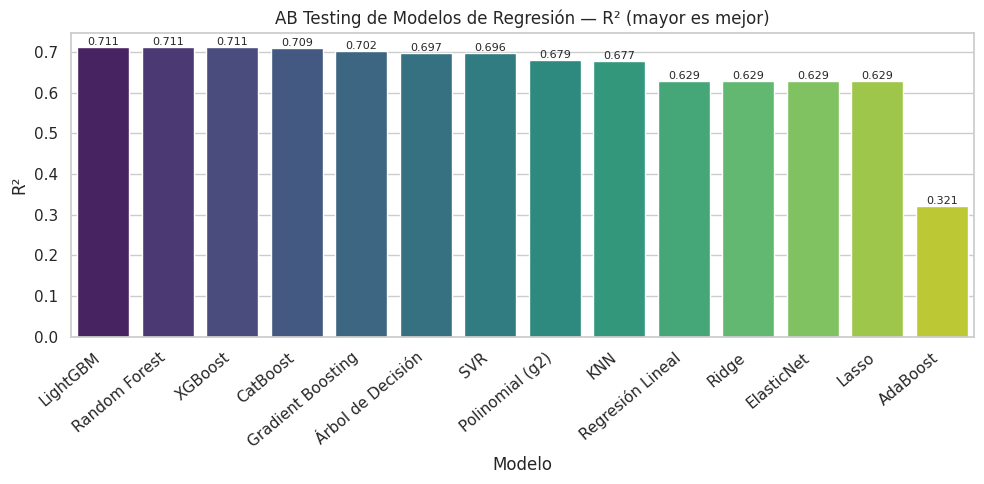

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_resultados_reg, x="Modelo", y="R2", palette="viridis", ax=ax)
ax.set_title('AB Testing de Modelos de Regresión — R² (mayor es mejor)')
ax.set_ylabel("R²")
plt.xticks(rotation=40, ha="right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


### A.3 AdaBoost Regressor — a fondo

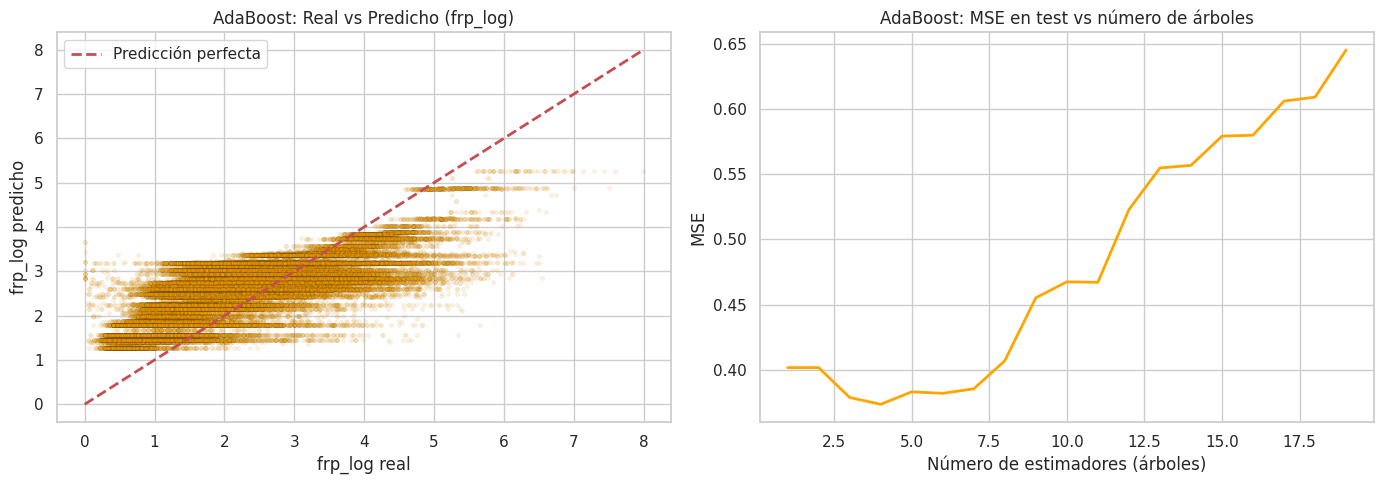

In [46]:
y_pred_ada_reg = ada_reg.predict(Xr_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yr_test, y_pred_ada_reg, alpha=0.15, s=8, color="orange", edgecolor="k", linewidth=0.2)
lims = [yr_test.min(), yr_test.max()]
axes[0].plot(lims, lims, "r--", lw=2, label="Predicción perfecta")
axes[0].set_title("AdaBoost: Real vs Predicho (frp_log)")
axes[0].set_xlabel("frp_log real")
axes[0].set_ylabel("frp_log predicho")
axes[0].legend()

# Curva de aprendizaje: error por número de árboles añadidos (staged_predict)
mse_por_iteracion = [
    mean_squared_error(yr_test, pred_parcial)
    for pred_parcial in ada_reg.staged_predict(Xr_test)
]
axes[1].plot(range(1, len(mse_por_iteracion) + 1), mse_por_iteracion, color="orange", linewidth=2)
axes[1].set_title("AdaBoost: MSE en test vs número de árboles")
axes[1].set_xlabel("Número de estimadores (árboles)")
axes[1].set_ylabel("MSE")
plt.tight_layout()
plt.show()


### A.4 Gradient Boosting Regressor — a fondo

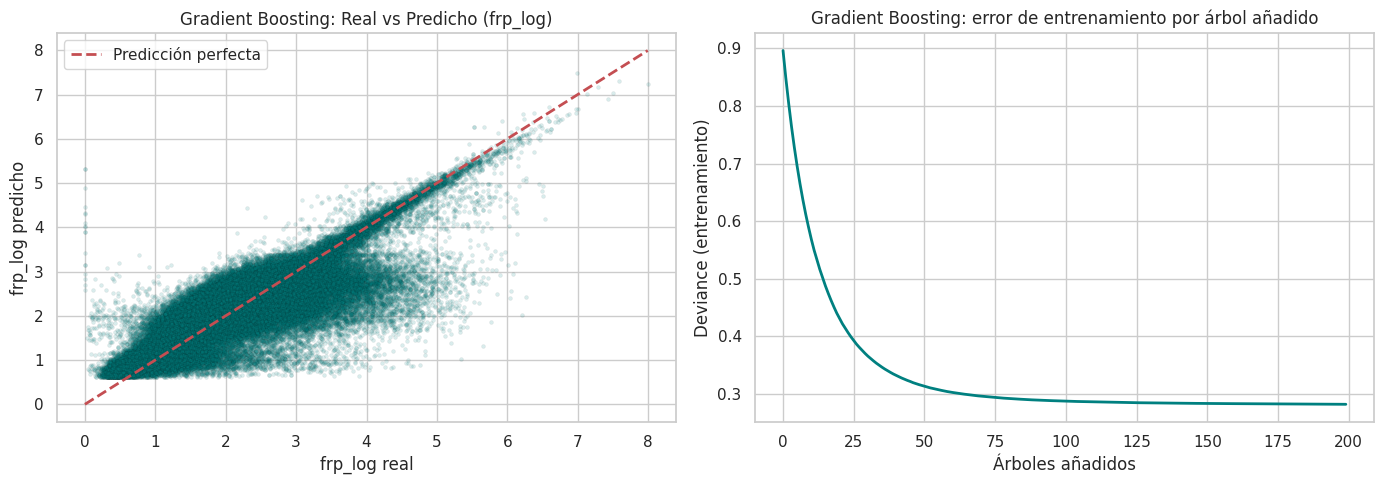

In [48]:
y_pred_gb_reg = gb_reg.predict(Xr_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(yr_test, y_pred_gb_reg, alpha=0.15, s=8, color="teal", edgecolor="k", linewidth=0.2)
axes[0].plot(lims, lims, "r--", lw=2, label="Predicción perfecta")
axes[0].set_title("Gradient Boosting: Real vs Predicho (frp_log)")
axes[0].set_xlabel("frp_log real")
axes[0].set_ylabel("frp_log predicho")
axes[0].legend()

axes[1].plot(gb_reg.train_score_, color="teal", linewidth=2)
axes[1].set_title("Gradient Boosting: error de entrenamiento por árbol añadido")
axes[1].set_xlabel("Árboles añadidos")
axes[1].set_ylabel("Deviance (entrenamiento)")
plt.tight_layout()
plt.show()


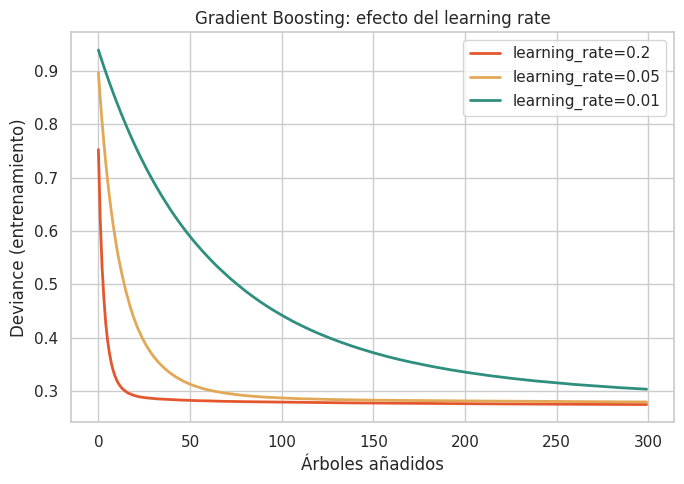

In [49]:
# Efecto del learning_rate: cuántos árboles necesita cada uno para converger
learning_rates = [0.2, 0.05, 0.01]
colores_lr = ["#e4572e", "#e3a857", "#2f8f7f"]

plt.figure(figsize=(7, 5))
for lr, color in zip(learning_rates, colores_lr):
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=lr, max_depth=3, random_state=RANDOM_STATE)
    m.fit(Xr_train, yr_train)
    plt.plot(m.train_score_, label=f"learning_rate={lr}", color=color, linewidth=2)
plt.xlabel("Árboles añadidos")
plt.ylabel("Deviance (entrenamiento)")
plt.title("Gradient Boosting: efecto del learning rate")
plt.legend()
plt.tight_layout()
plt.show()


### A.5 SVR — a fondo (comparación de kernel y de C)

In [50]:
resultados_svr_kernel = []
for kernel in ["linear", "rbf", "poly"]:
    m = SVR(kernel=kernel, C=10, gamma="scale")
    m.fit(Xr_train_small_s, yr_train_small)
    pred = m.predict(Xr_test_s)
    r = evaluate_regression(yr_test, pred, f"SVR ({kernel})")
    resultados_svr_kernel.append(r)

df_svr_kernel = pd.DataFrame(resultados_svr_kernel)
df_svr_kernel


,Modelo,MAE,MSE,RMSE,R2,MAPE (%)
0,SVR (linear),0.409863,0.368573,0.607102,0.612430,2.064197e+14
1,SVR (rbf),0.353248,0.288679,0.537288,0.696442,2.099199e+14
2,SVR (poly),0.482182,0.622317,0.788871,0.345607,3.202154e+14


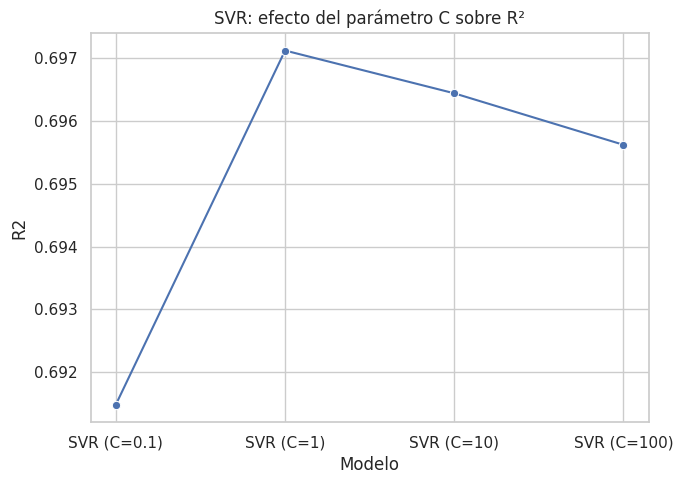

,Modelo,MAE,MSE,RMSE,R2,MAPE (%)
0,SVR (C=0.1),0.358172,0.293396,0.541661,0.691481,2.260886e+14
1,SVR (C=1),0.353640,0.288030,0.536685,0.697124,2.486835e+14
2,SVR (C=10),0.353248,0.288679,0.537288,0.696442,2.099199e+14
3,SVR (C=100),0.354104,0.289459,0.538014,0.695621,2.017997e+14


In [51]:
resultados_svr_c = []
for c_val in [0.1, 1, 10, 100]:
    m = SVR(kernel="rbf", C=c_val, gamma="scale")
    m.fit(Xr_train_small_s, yr_train_small)
    pred = m.predict(Xr_test_s)
    r = evaluate_regression(yr_test, pred, f"SVR (C={c_val})")
    resultados_svr_c.append(r)

df_svr_c = pd.DataFrame(resultados_svr_c)

fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(data=df_svr_c, x="Modelo", y="R2", marker="o", ax=ax)
ax.set_title("SVR: efecto del parámetro C sobre R²")
plt.tight_layout()
plt.show()

df_svr_c


### A.6 Conclusión de la sección de regresión (plantilla a completar)

- ¿Qué modelo obtuvo el mejor R² / menor RMSE en la tabla comparativa (A.2)?
- ¿AdaBoost o Gradient Boosting convergió más rápido (según la curva de iteraciones)?
- ¿Qué kernel de SVR funcionó mejor y por qué crees que fue así dado el tipo de relación entre las variables?
- Recuerda: para reportar `frp` en Megavatios reales, aplica `np.expm1()` a las predicciones.

---
## PARTE B — CLASIFICACIÓN: predecir `daynight_num`

**X:** `brightness, bright_t31, frp_log, scan, track, confidence_num`
**y:** `daynight_num` (1 = Día, 0 = Noche)


### B.1 Preparación de datos

In [52]:
features_clf = ['brightness', 'bright_t31', 'frp_log', 'scan', 'track', 'confidence_num']
target_clf = 'daynight_num'

X_clf = df[features_clf]
y_clf = df[target_clf]

print("Balance de clases:")
print(y_clf.value_counts(normalize=True))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
Xc_train_s = scaler_clf.fit_transform(Xc_train)
Xc_test_s = scaler_clf.transform(Xc_test)

print("Train:", Xc_train.shape, " Test:", Xc_test.shape)


Balance de clases:
daynight_num
1    0.588488
0    0.411512
Name: proportion, dtype: float64
Train: (537428, 6)  Test: (134358, 6)


### B.2 Comparación general ("AB Testing") — todos los modelos de clasificación

Igual que en regresión: línea base con todos los modelos, luego profundización en AdaBoost, Gradient Boosting y SVM.

> **KNN y SVM** se entrenan sobre una muestra de 30,000 filas (estratificada) por costo computacional.

In [53]:
from sklearn.neighbors import KNeighborsClassifier
idxc_sample, _ = train_test_split(
    Xc_train.index, train_size=min(30_000, len(Xc_train)),
    random_state=RANDOM_STATE, stratify=yc_train
)
Xc_train_small = Xc_train.loc[idxc_sample]
yc_train_small = yc_train.loc[idxc_sample]
Xc_train_small_s = scaler_clf.transform(Xc_train_small)

resultados_clf = []

def run_model(model, X_train, y_train, X_test, name, needs_proba=True):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if needs_proba and hasattr(model, "predict_proba") else None
    resultados_clf.append(evaluate_classification(yc_test, pred, proba, name))
    return model, pred, proba

# --- Lineales / probabilísticos ---
log_reg, pred_log, proba_log = run_model(LogisticRegression(max_iter=1000), Xc_train_s, yc_train, Xc_test_s, "Regresión Logística")
nb, pred_nb, proba_nb = run_model(GaussianNB(), Xc_train_s, yc_train, Xc_test_s, "Naive Bayes")

# --- KNN (muestra) ---
knn_clf, pred_knn, proba_knn = run_model(KNeighborsClassifier(n_neighbors=15), Xc_train_small_s, yc_train_small, Xc_test_s, "KNN")

# --- Árboles / ensambles ---
tree_clf, pred_tree, proba_tree = run_model(DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE), Xc_train, yc_train, Xc_test, "Árbol de Decisión")
rf_clf, pred_rf, proba_rf = run_model(RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1), Xc_train, yc_train, Xc_test, "Random Forest")

# --- Boosting ---
ada_clf, pred_ada, proba_ada = run_model(AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE), Xc_train, yc_train, Xc_test, "AdaBoost")
gb_clf, pred_gb, proba_gb = run_model(GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE), Xc_train, yc_train, Xc_test, "Gradient Boosting")
xgb_clf, pred_xgb, proba_xgb = run_model(XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE, verbosity=0, eval_metric="logloss"), Xc_train, yc_train, Xc_test, "XGBoost")
lgbm_clf, pred_lgbm, proba_lgbm = run_model(LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1), Xc_train, yc_train, Xc_test, "LightGBM")
cat_clf, pred_cat, proba_cat = run_model(CatBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbose=0), Xc_train, yc_train, Xc_test, "CatBoost")

# --- SVM (muestra) ---
svm_clf, pred_svm, proba_svm = run_model(SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=RANDOM_STATE), Xc_train_small_s, yc_train_small, Xc_test_s, "SVM")

df_resultados_clf = pd.DataFrame(resultados_clf).sort_values("F1-Score", ascending=False).reset_index(drop=True)
df_resultados_clf


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,LightGBM,0.919037,0.908627,0.958846,0.933061,0.976473
1,XGBoost,0.917861,0.906307,0.959630,0.932206,0.975599
2,Random Forest,0.917199,0.902520,0.963348,0.931943,0.975187
3,CatBoost,0.916827,0.905172,0.959149,0.931379,0.975051
4,Gradient Boosting,0.911967,0.901653,0.954520,0.927334,0.971968
5,Árbol de Decisión,0.910225,0.896410,0.958175,0.926264,0.970047
6,SVM,0.907501,0.886875,0.966042,0.924767,0.967153
7,KNN,0.908297,0.901244,0.948057,0.924058,0.966640
8,AdaBoost,0.897967,0.895918,0.935271,0.915172,0.963687
9,Regresión Logística,0.890003,0.888552,0.929693,0.908657,0.939989


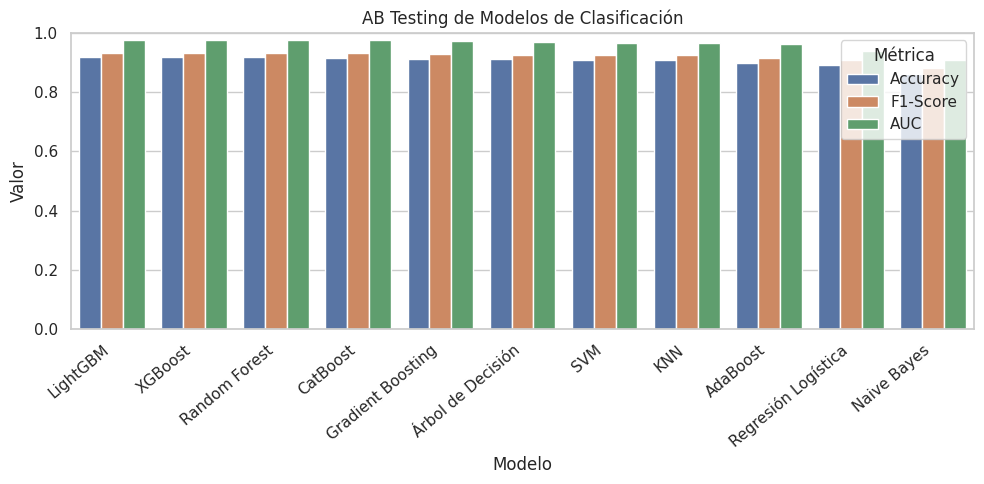

In [54]:
from sklearn.neighbors import KNeighborsClassifier  # (import usado arriba; se deja explícito aquí por claridad)

fig, ax = plt.subplots(figsize=(10, 5))
metrics_melt = df_resultados_clf.melt(id_vars="Modelo", value_vars=["Accuracy", "F1-Score", "AUC"],
                                        var_name="Métrica", value_name="Valor")
sns.barplot(data=metrics_melt, x="Modelo", y="Valor", hue="Métrica", ax=ax)
ax.set_title("AB Testing de Modelos de Clasificación")
ax.set_ylim(0, 1)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### B.2bis Matrices de Confusión — TODOS los modelos (daynight_num)

Una matriz de confusión por cada modelo entrenado en el AB Testing anterior, para ver de un vistazo en qué se equivoca cada uno (no solo AdaBoost y Gradient Boosting).

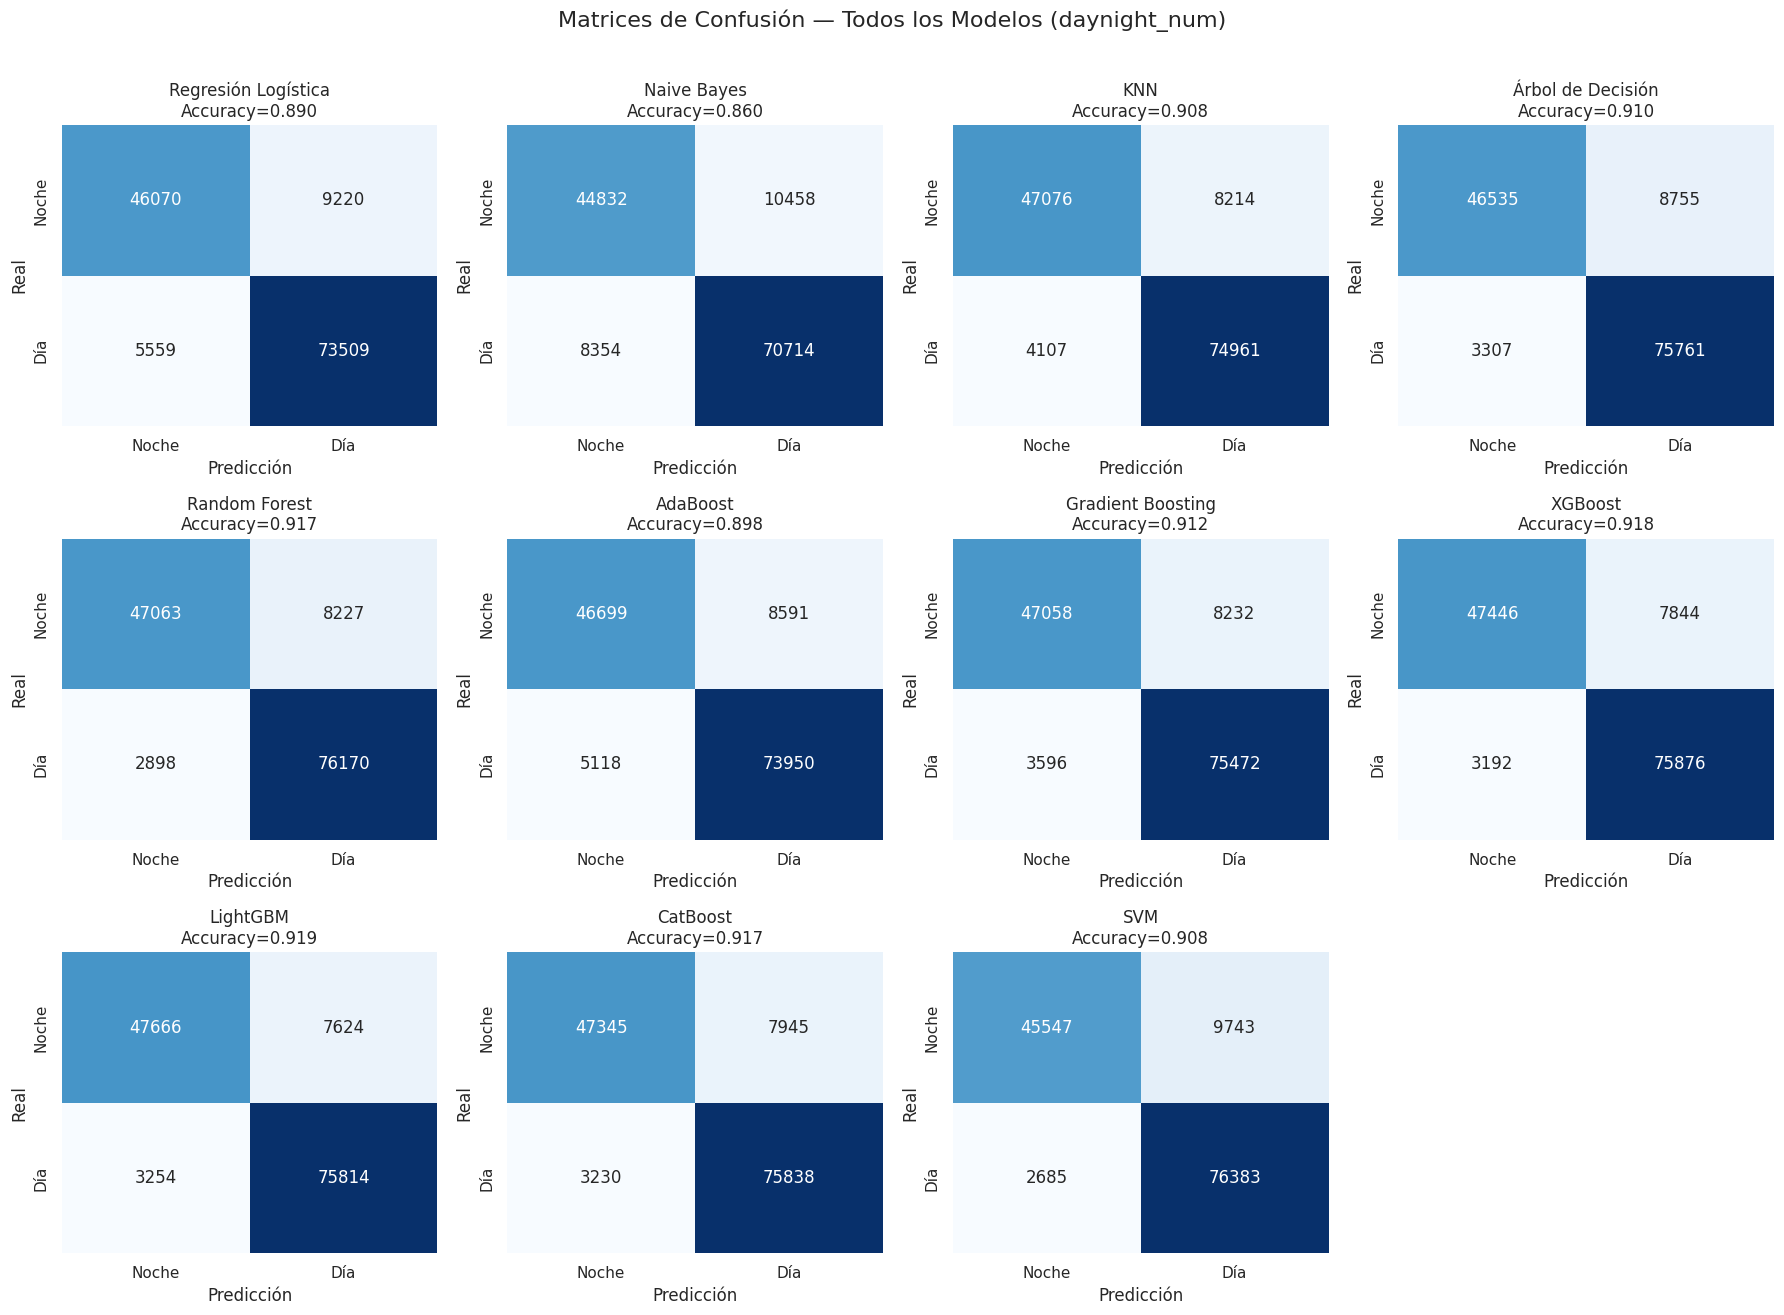

In [55]:
modelos_b2 = [
    ("Regresión Logística", pred_log),
    ("Naive Bayes", pred_nb),
    ("KNN", pred_knn),
    ("Árbol de Decisión", pred_tree),
    ("Random Forest", pred_rf),
    ("AdaBoost", pred_ada),
    ("Gradient Boosting", pred_gb),
    ("XGBoost", pred_xgb),
    ("LightGBM", pred_lgbm),
    ("CatBoost", pred_cat),
    ("SVM", pred_svm),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for ax, (nombre, pred) in zip(axes, modelos_b2):
    cm = confusion_matrix(yc_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Noche", "Día"], yticklabels=["Noche", "Día"])
    acc = accuracy_score(yc_test, pred)
    ax.set_title(f"{nombre}\nAccuracy={acc:.3f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

# Se ocultan los subplots sobrantes (11 modelos en una grilla de 12)
for ax in axes[len(modelos_b2):]:
    ax.axis("off")

plt.suptitle("Matrices de Confusión — Todos los Modelos (daynight_num)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### B.3 AdaBoost Classifier — a fondo

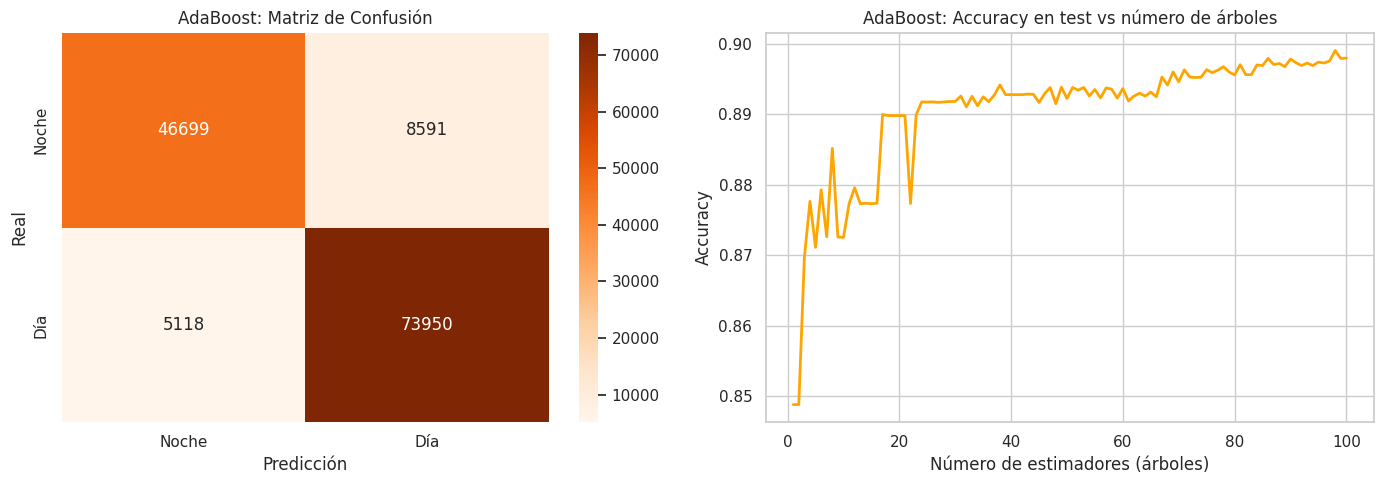

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_ada = confusion_matrix(yc_test, pred_ada)
sns.heatmap(cm_ada, annot=True, fmt="d", cmap="Oranges", ax=axes[0],
            xticklabels=["Noche", "Día"], yticklabels=["Noche", "Día"])
axes[0].set_title("AdaBoost: Matriz de Confusión")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Curva de aprendizaje por iteración
acc_por_iteracion = [
    accuracy_score(yc_test, pred_parcial)
    for pred_parcial in ada_clf.staged_predict(Xc_test)
]
axes[1].plot(range(1, len(acc_por_iteracion) + 1), acc_por_iteracion, color="orange", linewidth=2)
axes[1].set_title("AdaBoost: Accuracy en test vs número de árboles")
axes[1].set_xlabel("Número de estimadores (árboles)")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()


### B.4 Gradient Boosting Classifier — a fondo

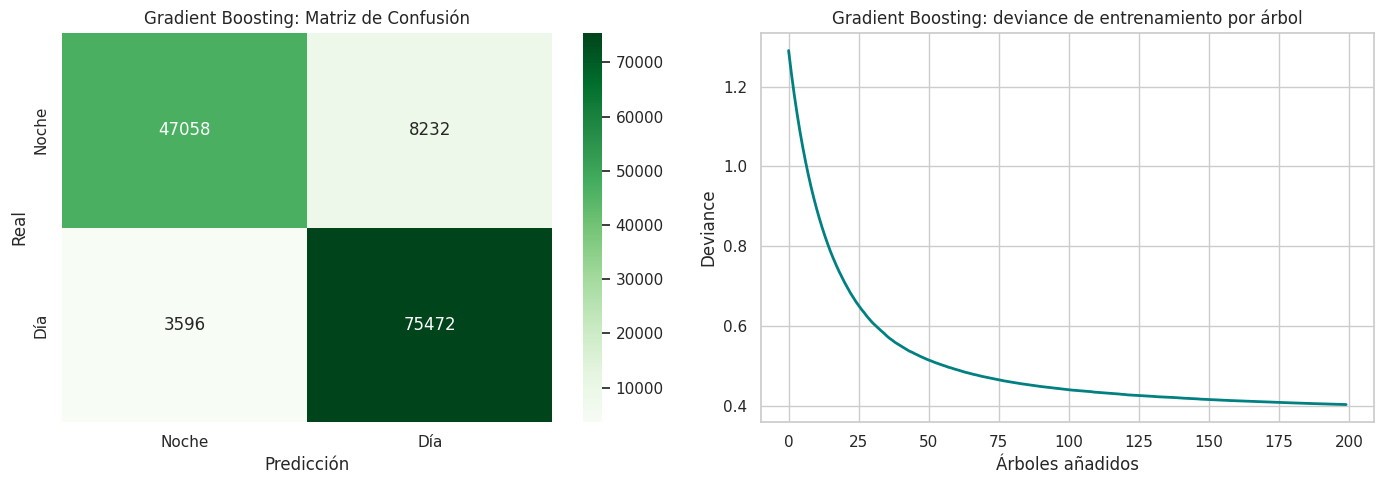

In [57]:
gb_clf_track = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
gb_clf_track.fit(Xc_train, yc_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gb = confusion_matrix(yc_test, pred_gb)
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Noche", "Día"], yticklabels=["Noche", "Día"])
axes[0].set_title("Gradient Boosting: Matriz de Confusión")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

axes[1].plot(gb_clf_track.train_score_, color="teal", linewidth=2)
axes[1].set_title("Gradient Boosting: deviance de entrenamiento por árbol")
axes[1].set_xlabel("Árboles añadidos")
axes[1].set_ylabel("Deviance")
plt.tight_layout()
plt.show()


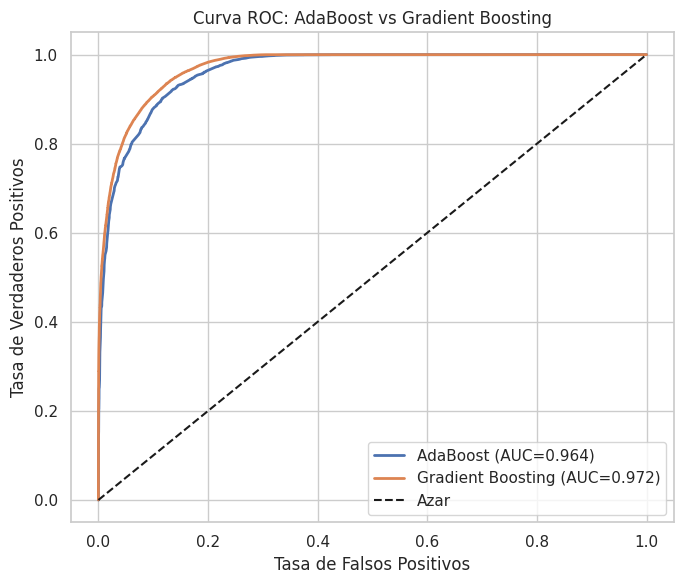

In [58]:
# Curvas ROC comparadas: AdaBoost vs Gradient Boosting
plt.figure(figsize=(7, 6))
for nombre, proba in [("AdaBoost", proba_ada), ("Gradient Boosting", proba_gb)]:
    fpr, tpr, _ = roc_curve(yc_test, proba)
    auc_val = roc_auc_score(yc_test, proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc_val:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Azar")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC: AdaBoost vs Gradient Boosting")
plt.legend()
plt.tight_layout()
plt.show()


### B.5 SVM — a fondo (comparación de kernel y de C)

In [59]:
resultados_svm_kernel = []
for kernel in ["linear", "rbf", "poly"]:
    m = SVC(kernel=kernel, C=1, gamma="scale", probability=True, random_state=RANDOM_STATE)
    m.fit(Xc_train_small_s, yc_train_small)
    pred = m.predict(Xc_test_s)
    proba = m.predict_proba(Xc_test_s)[:, 1]
    resultados_svm_kernel.append(evaluate_classification(yc_test, pred, proba, f"SVM ({kernel})"))

df_svm_kernel = pd.DataFrame(resultados_svm_kernel)
df_svm_kernel


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,SVM (linear),0.890464,0.882055,0.939495,0.909869,0.939707
1,SVM (rbf),0.907501,0.886875,0.966042,0.924767,0.967153
2,SVM (poly),0.867384,0.828151,0.977488,0.896644,0.940305


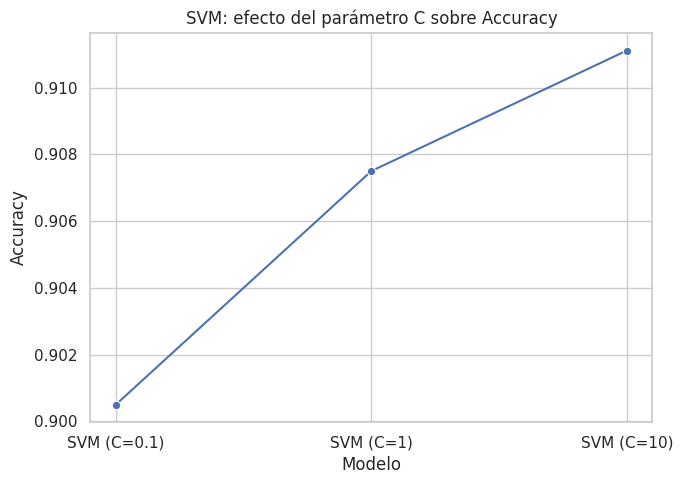

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,SVM (C=0.1),0.900505,0.878928,0.963677,0.919353,0.961813
1,SVM (C=1),0.907501,0.886875,0.966042,0.924767,0.967153
2,SVM (C=10),0.911111,0.890021,0.968647,0.927671,0.968302


In [60]:
resultados_svm_c = []
for c_val in [0.1, 1, 10]:
    m = SVC(kernel="rbf", C=c_val, gamma="scale", probability=True, random_state=RANDOM_STATE)
    m.fit(Xc_train_small_s, yc_train_small)
    pred = m.predict(Xc_test_s)
    proba = m.predict_proba(Xc_test_s)[:, 1]
    resultados_svm_c.append(evaluate_classification(yc_test, pred, proba, f"SVM (C={c_val})"))

df_svm_c = pd.DataFrame(resultados_svm_c)

fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(data=df_svm_c, x="Modelo", y="Accuracy", marker="o", ax=ax)
ax.set_title("SVM: efecto del parámetro C sobre Accuracy")
plt.tight_layout()
plt.show()

df_svm_c


### B.6 Importancia de variables (modelos de árboles/boosting)

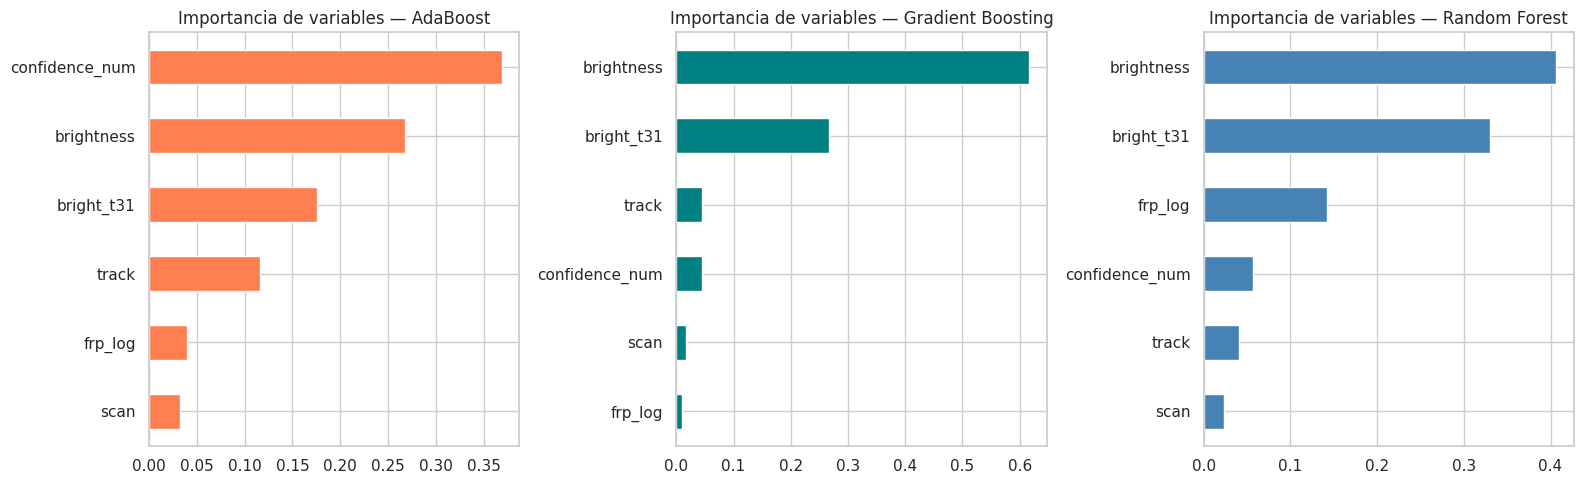

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nombre, modelo, color) in zip(
    axes,
    [("AdaBoost", ada_clf, "coral"), ("Gradient Boosting", gb_clf, "teal"), ("Random Forest", rf_clf, "steelblue")]
):
    importancias = pd.Series(modelo.feature_importances_, index=features_clf).sort_values()
    importancias.plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Importancia de variables — {nombre}")
plt.tight_layout()
plt.show()


### B.7 Conclusión de la sección de clasificación (plantilla a completar)

- ¿Qué modelo tuvo mejor Accuracy/F1/AUC en la tabla comparativa (B.2)?
- ¿Cuántos árboles necesitó AdaBoost para estabilizar su accuracy?
- ¿Qué kernel de SVM funcionó mejor? ¿Coincide con lo esperado dado que la frontera Día/Noche depende mucho de `brightness`?
- ¿Qué variable resultó más importante para distinguir Día/Noche según los tres modelos de la sección B.6?


---
## Conclusión general del proyecto

Resume aquí, en 4-5 líneas:
1. Mejor modelo de regresión y por qué.
2. Mejor modelo de clasificación y por qué.
3. Ventajas/desventajas observadas de AdaBoost vs Gradient Boosting vs SVM en este dataset específico (600k registros de sensores satelitales).
4. Limitaciones (ej. SVM/KNN con muestra reducida) y cómo se podrían superar con más recursos computacionales (ej. `LinearSVR`/`SGDClassifier` para escalar, o Dask/GPU).


---
## PARTE C — CLASIFICACIÓN MULTICLASE: `nivel_frp` (discretización de FRP)

En lugar de predecir Día/Noche, aquí se replica la idea de discretizar `frp` en 3 niveles de intensidad (**Bajo / Medio / Alto**), convirtiendo el problema en una **clasificación multiclase**. Se aplica el mismo set completo de modelos usado en la Parte B (incluyendo AdaBoost, Gradient Boosting y SVM), no solo Naive Bayes.

> ⚠️ **Importante — fuga de datos (data leakage):** como `nivel_frp` se construye a partir de `frp`, **no se puede usar `frp` ni `frp_log` como variable de entrada** (el modelo "vería" directamente la respuesta). Por eso, además de `brightness, bright_t31, scan, track, confidence_num`, se agregan variables temporales (`mes`, `hora`) y categóricas (`daynight`, `satellite`, `instrument`) para compensar la pérdida de esa variable.


### C.1 Crear la variable objetivo `nivel_frp` y variables temporales

In [62]:
# --- Discretización de FRP en 3 niveles ---
print("Percentiles de frp:")
print(df["frp"].quantile([0.10, 0.25, 0.33, 0.50, 0.67, 0.75, 0.90]))

# Cortes por terciles (33% y 67%). Si tu compañero usó valores fijos (ej. 3.79 y 9.84)
# y quieren resultados 100% comparables entre los notebooks del grupo, reemplaza estas
# dos líneas por: corte_bajo, corte_medio = 3.79, 9.84
corte_bajo = df["frp"].quantile(0.33)
corte_medio = df["frp"].quantile(0.67)
print(f"\nCortes usados -> Bajo/Medio: {corte_bajo:.2f}   Medio/Alto: {corte_medio:.2f}")

df["nivel_frp"] = pd.cut(
    df["frp"],
    bins=[-np.inf, corte_bajo, corte_medio, np.inf],
    labels=[0, 1, 2]
).astype(int)

print("\nDistribución de nivel_frp (0=Bajo, 1=Medio, 2=Alto):")
print(df["nivel_frp"].value_counts().sort_index())
print(df["nivel_frp"].value_counts(normalize=True).sort_index().mul(100).round(2))


Percentiles de frp:
0.10     1.33
0.25     2.83
0.33     3.79
0.50     6.16
0.67     9.84
0.75    12.82
0.90    27.53
Name: frp, dtype: float64

Cortes usados -> Bajo/Medio: 3.79   Medio/Alto: 9.84

Distribución de nivel_frp (0=Bajo, 1=Medio, 2=Alto):
nivel_frp
0    221708
1    228478
2    221600
Name: count, dtype: int64
nivel_frp
0    33.00
1    34.01
2    32.99
Name: proportion, dtype: float64


In [63]:
# --- Variables temporales (mismo enfoque que el notebook del compañero) ---
try:
    df["acq_date"] = pd.to_datetime(df["acq_date"], format="%d/%m/%Y")
except (ValueError, TypeError):
    df["acq_date"] = pd.to_datetime(df["acq_date"])

df["mes"] = df["acq_date"].dt.month

hora_texto = df["acq_time"].astype(int).astype(str).str.zfill(4)
df["hora"] = hora_texto.str[:2].astype(int)

df[["acq_date", "acq_time", "mes", "hora", "frp", "nivel_frp"]].head(10)


,acq_date,acq_time,mes,hora,frp,nivel_frp
0,2025-01-01,529,1,5,1.56,0
1,2025-01-01,529,1,5,0.75,0
2,2025-01-01,530,1,5,2.89,0
3,2025-01-01,530,1,5,2.89,0
4,2025-01-01,530,1,5,1.29,0
5,2025-01-01,530,1,5,4.64,1
6,2025-01-01,530,1,5,4.64,1
7,2025-01-01,530,1,5,1.95,0
8,2025-01-01,530,1,5,0.94,0
9,2025-01-01,530,1,5,1.95,0


### C.2 Preparación de datos (features numéricas + One-Hot de categóricas)

In [64]:
features_num_mc = ['brightness', 'bright_t31', 'scan', 'track', 'confidence_num', 'mes', 'hora']
features_cat_mc = ['daynight', 'satellite', 'instrument']

df_mc = df.dropna(subset=features_num_mc + features_cat_mc + ['nivel_frp']).copy()

X_mc = df_mc[features_num_mc + features_cat_mc].copy()
y_mc = df_mc['nivel_frp']

X_mc = pd.get_dummies(X_mc, columns=features_cat_mc, dtype=int)
dummy_cols_mc = [c for c in X_mc.columns if c not in features_num_mc]

print("Cantidad de variables:", X_mc.shape[1])
print(X_mc.columns.tolist())

Xmc_train, Xmc_test, ymc_train, ymc_test = train_test_split(
    X_mc, y_mc, test_size=0.20, random_state=RANDOM_STATE, stratify=y_mc
)

# Escalado: solo a las variables numéricas continuas; las dummies quedan tal cual (0/1)
scaler_mc = StandardScaler()
Xmc_train_num_s = scaler_mc.fit_transform(Xmc_train[features_num_mc])
Xmc_test_num_s = scaler_mc.transform(Xmc_test[features_num_mc])

Xmc_train_s = np.hstack([Xmc_train_num_s, Xmc_train[dummy_cols_mc].values])
Xmc_test_s = np.hstack([Xmc_test_num_s, Xmc_test[dummy_cols_mc].values])

print("Train:", Xmc_train_s.shape, " Test:", Xmc_test_s.shape)


Cantidad de variables: 17
['brightness', 'bright_t31', 'scan', 'track', 'confidence_num', 'mes', 'hora', 'daynight_D', 'daynight_N', 'satellite_Aqua', 'satellite_N20', 'satellite_N21', 'satellite_SNPP', 'satellite_Terra', 'instrument_MODIS', 'instrument_SNPP', 'instrument_VIIRS']
Train: (537428, 17)  Test: (134358, 17)


### C.3 Función de evaluación para clasificación multiclase

In [65]:
def evaluate_classification_multiclass(y_true, y_pred, y_proba, model_name):
    resultado = {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    if y_proba is not None:
        try:
            resultado["AUC (macro OVR)"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        except ValueError:
            resultado["AUC (macro OVR)"] = np.nan
    else:
        resultado["AUC (macro OVR)"] = np.nan
    return resultado


### C.4 Comparación general ("AB Testing") — todos los modelos, target `nivel_frp`

> **KNN y SVM** se entrenan sobre una muestra de 30,000 filas (estratificada) por costo computacional, igual que en la Parte B.

In [66]:
SAMPLE_SIZE_MC = 30_000
idx_mc_sample, _ = train_test_split(
    np.arange(len(Xmc_train_s)), train_size=min(SAMPLE_SIZE_MC, len(Xmc_train_s)),
    random_state=RANDOM_STATE, stratify=ymc_train
)
Xmc_train_small_s = Xmc_train_s[idx_mc_sample]
ymc_train_small = ymc_train.iloc[idx_mc_sample]

resultados_mc = []

def run_model_mc(model, X_train, y_train, X_test, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    resultados_mc.append(evaluate_classification_multiclass(ymc_test, pred, proba, name))
    return model, pred, proba

log_reg_mc, pred_log_mc, proba_log_mc = run_model_mc(
    LogisticRegression(max_iter=2000), Xmc_train_s, ymc_train, Xmc_test_s, "Regresión Logística")

nb_mc, pred_nb_mc, proba_nb_mc = run_model_mc(
    GaussianNB(), Xmc_train_s, ymc_train, Xmc_test_s, "Naive Bayes")

knn_mc, pred_knn_mc, proba_knn_mc = run_model_mc(
    KNeighborsClassifier(n_neighbors=15), Xmc_train_small_s, ymc_train_small, Xmc_test_s, "KNN")

tree_mc, pred_tree_mc, proba_tree_mc = run_model_mc(
    DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE), Xmc_train_s, ymc_train, Xmc_test_s, "Árbol de Decisión")

rf_mc, pred_rf_mc, proba_rf_mc = run_model_mc(
    RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    Xmc_train_s, ymc_train, Xmc_test_s, "Random Forest")

ada_mc, pred_ada_mc, proba_ada_mc = run_model_mc(
    AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE), Xmc_train_s, ymc_train, Xmc_test_s, "AdaBoost")

gb_mc, pred_gb_mc, proba_gb_mc = run_model_mc(
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    Xmc_train_s, ymc_train, Xmc_test_s, "Gradient Boosting")

xgb_mc, pred_xgb_mc, proba_xgb_mc = run_model_mc(
    XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE,
                  verbosity=0, eval_metric="mlogloss"),
    Xmc_train_s, ymc_train, Xmc_test_s, "XGBoost")

lgbm_mc, pred_lgbm_mc, proba_lgbm_mc = run_model_mc(
    LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1),
    Xmc_train_s, ymc_train, Xmc_test_s, "LightGBM")

cat_mc, pred_cat_mc, proba_cat_mc = run_model_mc(
    CatBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbose=0),
    Xmc_train_s, ymc_train, Xmc_test_s, "CatBoost")

svm_mc, pred_svm_mc, proba_svm_mc = run_model_mc(
    SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=RANDOM_STATE),
    Xmc_train_small_s, ymc_train_small, Xmc_test_s, "SVM")

df_resultados_mc = pd.DataFrame(resultados_mc).sort_values("F1-Score", ascending=False).reset_index(drop=True)
df_resultados_mc


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC (macro OVR)
0,LightGBM,0.737708,0.747429,0.737708,0.739901,0.894571
1,Random Forest,0.735081,0.749420,0.735081,0.738341,0.892574
2,XGBoost,0.735014,0.745211,0.735014,0.737373,0.892704
3,CatBoost,0.734798,0.743404,0.734798,0.736842,0.892107
4,Gradient Boosting,0.730481,0.738520,0.730481,0.732445,0.888223
5,SVM,0.723239,0.745226,0.723239,0.727501,0.879914
6,Árbol de Decisión,0.720984,0.737889,0.720984,0.724939,0.880557
7,Regresión Logística,0.715052,0.728024,0.715052,0.718815,0.874960
8,KNN,0.709664,0.718091,0.709664,0.711309,0.868091
9,AdaBoost,0.699549,0.708668,0.699549,0.702757,0.837654


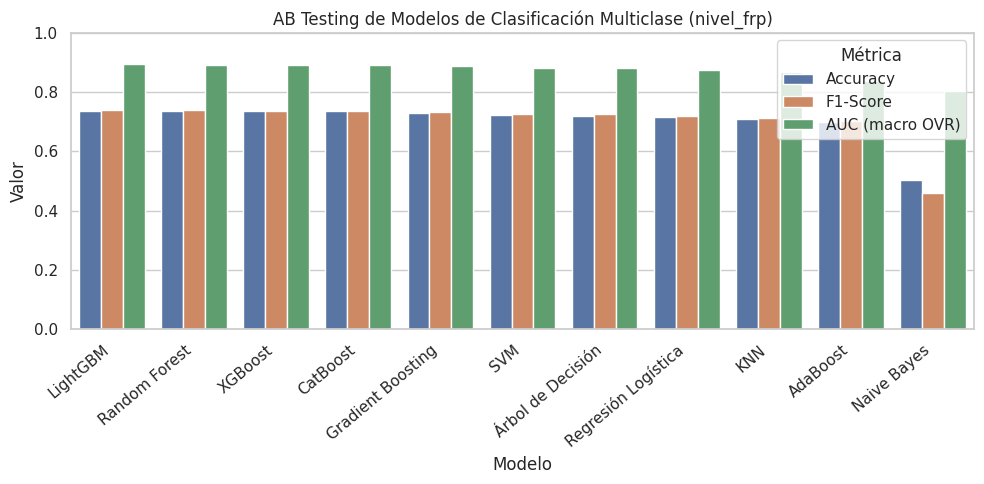

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_melt_mc = df_resultados_mc.melt(
    id_vars="Modelo", value_vars=["Accuracy", "F1-Score", "AUC (macro OVR)"],
    var_name="Métrica", value_name="Valor"
)
sns.barplot(data=metrics_melt_mc, x="Modelo", y="Valor", hue="Métrica", ax=ax)
ax.set_title("AB Testing de Modelos de Clasificación Multiclase (nivel_frp)")
ax.set_ylim(0, 1)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### C.4bis Matrices de Confusión — TODOS los modelos (nivel_frp)

Igual que en la Parte B, una matriz de confusión (3x3: Bajo/Medio/Alto) por cada modelo del AB Testing de esta sección.

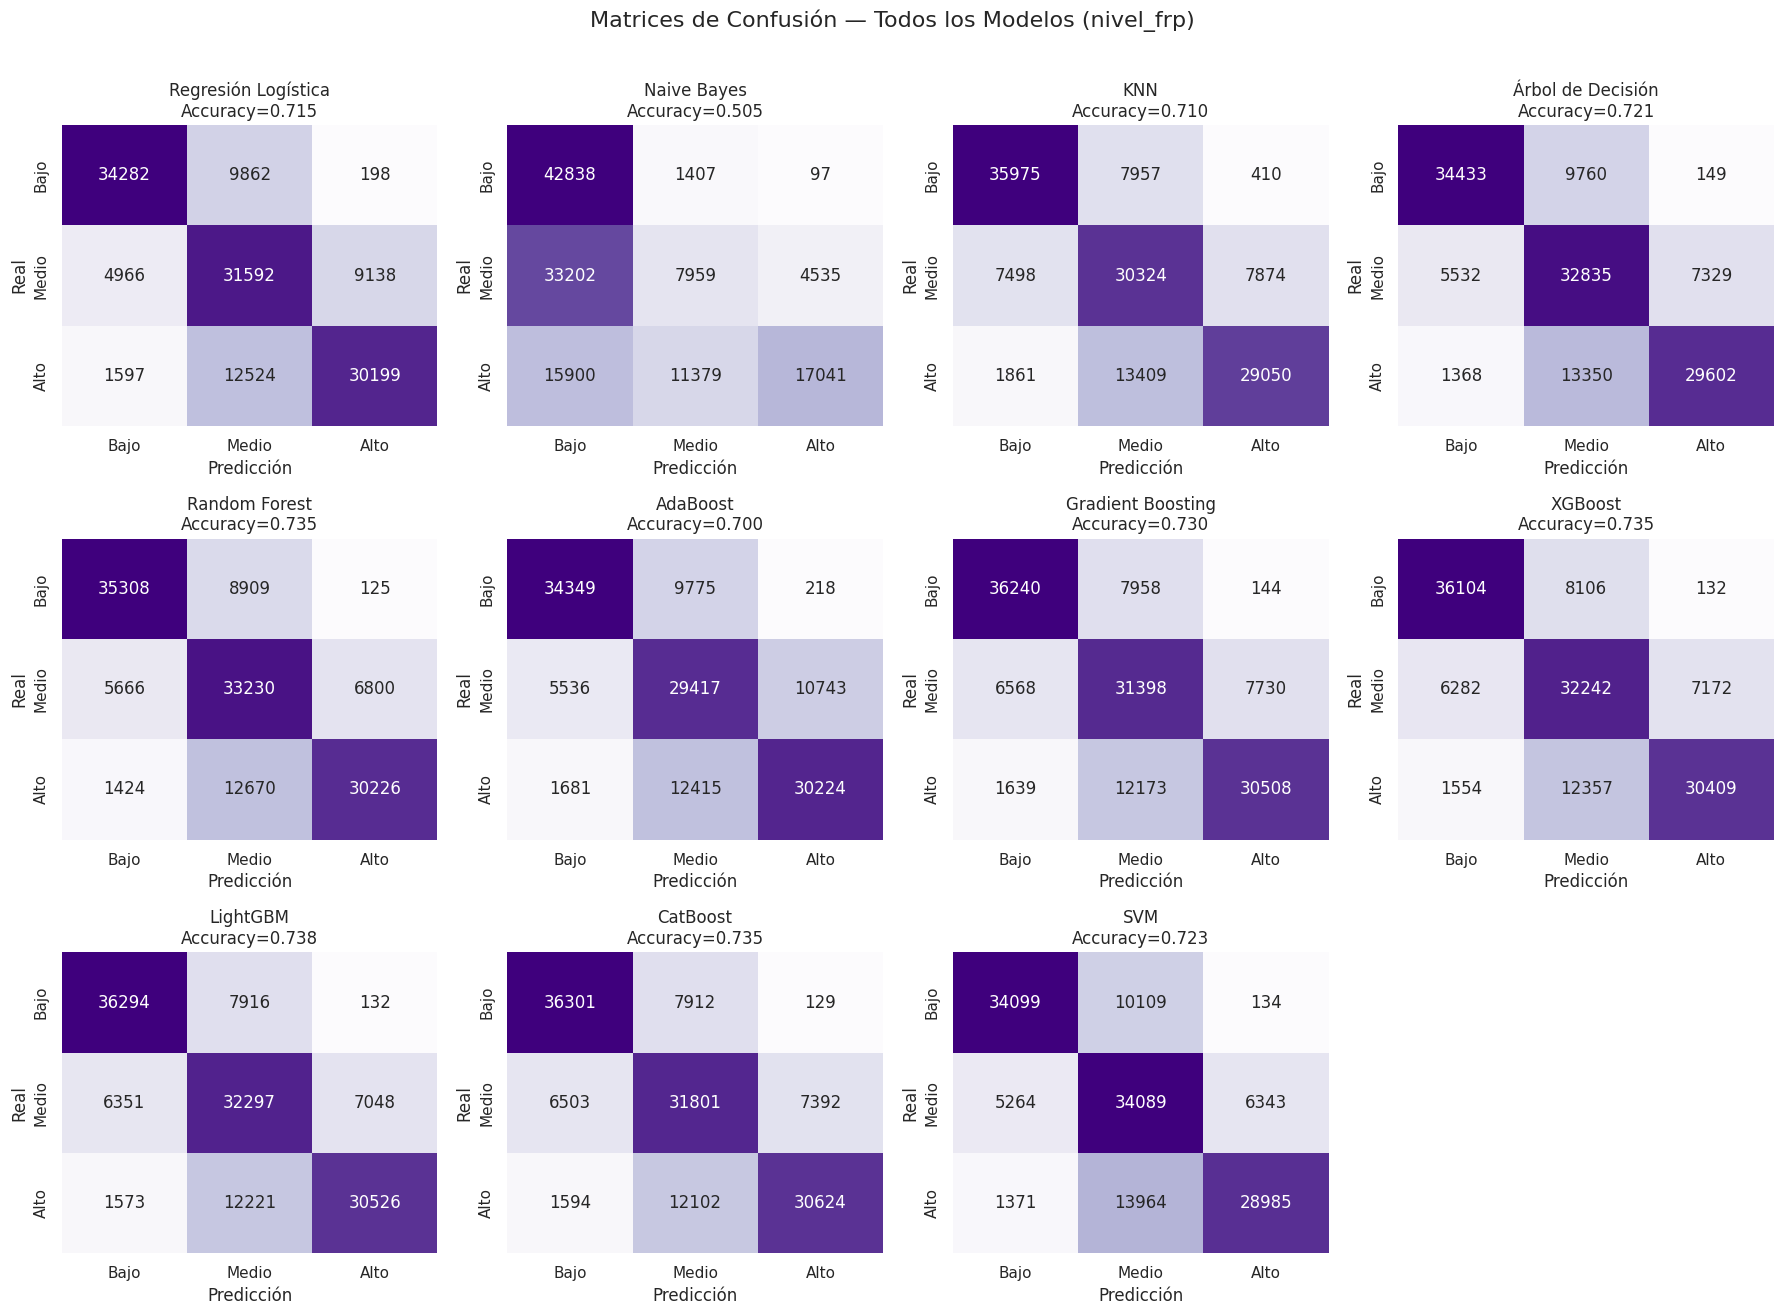

In [68]:
modelos_c4 = [
    ("Regresión Logística", pred_log_mc),
    ("Naive Bayes", pred_nb_mc),
    ("KNN", pred_knn_mc),
    ("Árbol de Decisión", pred_tree_mc),
    ("Random Forest", pred_rf_mc),
    ("AdaBoost", pred_ada_mc),
    ("Gradient Boosting", pred_gb_mc),
    ("XGBoost", pred_xgb_mc),
    ("LightGBM", pred_lgbm_mc),
    ("CatBoost", pred_cat_mc),
    ("SVM", pred_svm_mc),
]

etiquetas_frp_todos = ["Bajo", "Medio", "Alto"]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for ax, (nombre, pred) in zip(axes, modelos_c4):
    cm = confusion_matrix(ymc_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=ax, cbar=False,
                xticklabels=etiquetas_frp_todos, yticklabels=etiquetas_frp_todos)
    acc = accuracy_score(ymc_test, pred)
    ax.set_title(f"{nombre}\nAccuracy={acc:.3f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

for ax in axes[len(modelos_c4):]:
    ax.axis("off")

plt.suptitle("Matrices de Confusión — Todos los Modelos (nivel_frp)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### C.5 AdaBoost — a fondo (multiclase)

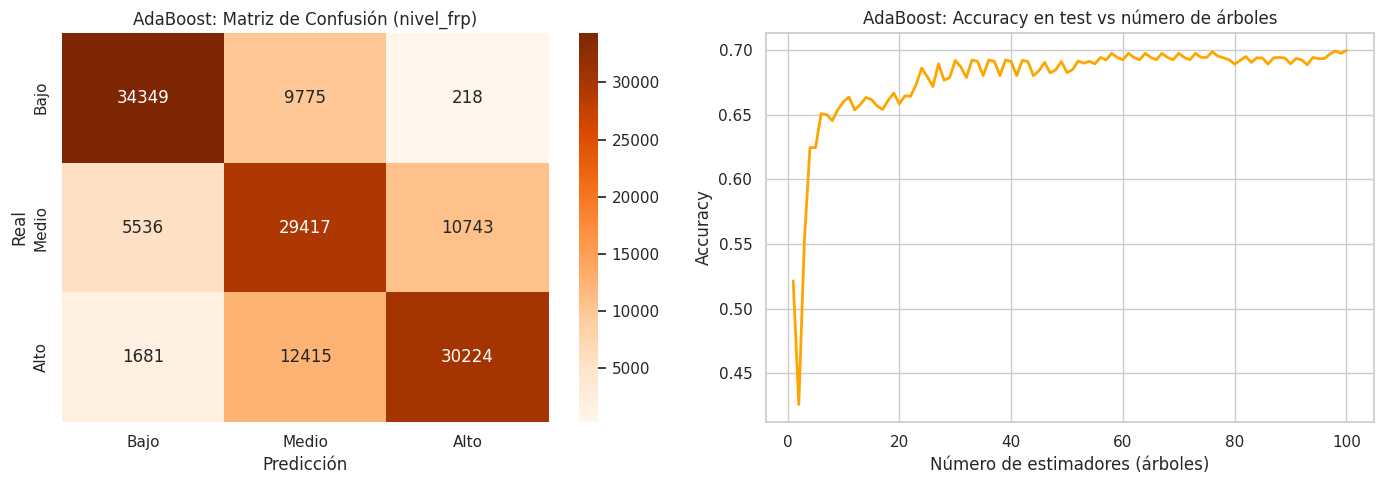

In [69]:
etiquetas_frp = ["Bajo", "Medio", "Alto"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_ada_mc = confusion_matrix(ymc_test, pred_ada_mc)
sns.heatmap(cm_ada_mc, annot=True, fmt="d", cmap="Oranges", ax=axes[0],
            xticklabels=etiquetas_frp, yticklabels=etiquetas_frp)
axes[0].set_title("AdaBoost: Matriz de Confusión (nivel_frp)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

acc_por_iteracion_mc = [
    accuracy_score(ymc_test, pred_parcial)
    for pred_parcial in ada_mc.staged_predict(Xmc_test_s)
]
axes[1].plot(range(1, len(acc_por_iteracion_mc) + 1), acc_por_iteracion_mc, color="orange", linewidth=2)
axes[1].set_title("AdaBoost: Accuracy en test vs número de árboles")
axes[1].set_xlabel("Número de estimadores (árboles)")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()


### C.6 Gradient Boosting — a fondo (multiclase)

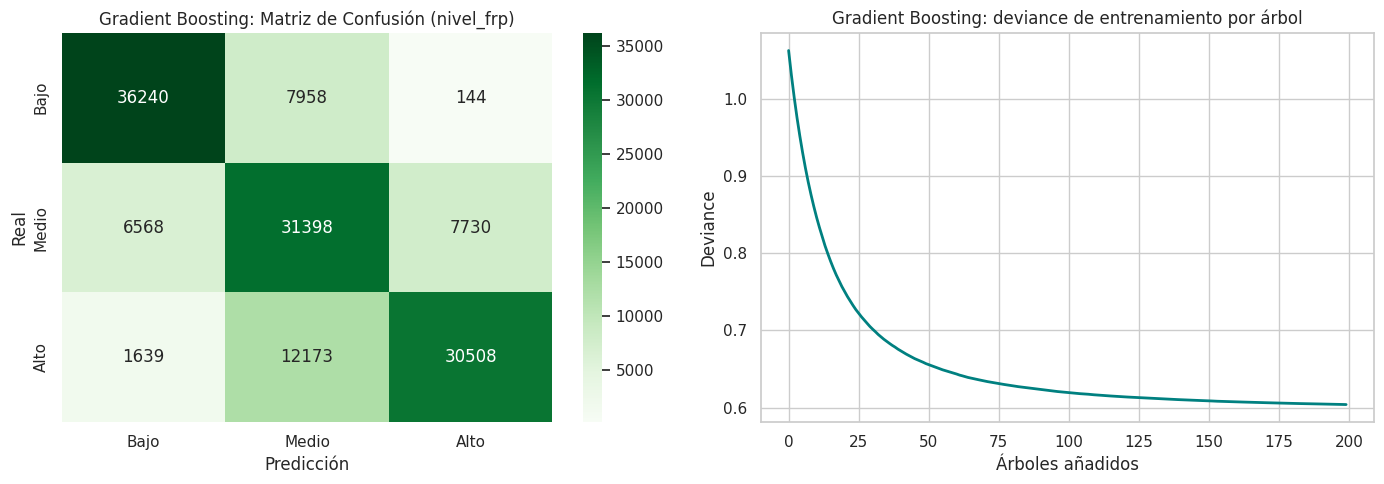

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gb_mc = confusion_matrix(ymc_test, pred_gb_mc)
sns.heatmap(cm_gb_mc, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=etiquetas_frp, yticklabels=etiquetas_frp)
axes[0].set_title("Gradient Boosting: Matriz de Confusión (nivel_frp)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

axes[1].plot(gb_mc.train_score_, color="teal", linewidth=2)
axes[1].set_title("Gradient Boosting: deviance de entrenamiento por árbol")
axes[1].set_xlabel("Árboles añadidos")
axes[1].set_ylabel("Deviance")
plt.tight_layout()
plt.show()


### C.7 SVM — a fondo (comparación de kernel y de C, multiclase)

In [71]:
resultados_svm_kernel_mc = []
for kernel in ["linear", "rbf", "poly"]:
    m = SVC(kernel=kernel, C=1, gamma="scale", probability=True, random_state=RANDOM_STATE)
    m.fit(Xmc_train_small_s, ymc_train_small)
    pred = m.predict(Xmc_test_s)
    proba = m.predict_proba(Xmc_test_s)
    resultados_svm_kernel_mc.append(evaluate_classification_multiclass(ymc_test, pred, proba, f"SVM ({kernel})"))

pd.DataFrame(resultados_svm_kernel_mc)


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC (macro OVR)
0,SVM (linear),0.711428,0.733733,0.711428,0.716201,0.873160
1,SVM (rbf),0.723239,0.745226,0.723239,0.727501,0.879914
2,SVM (poly),0.719935,0.745936,0.719935,0.724330,0.879928


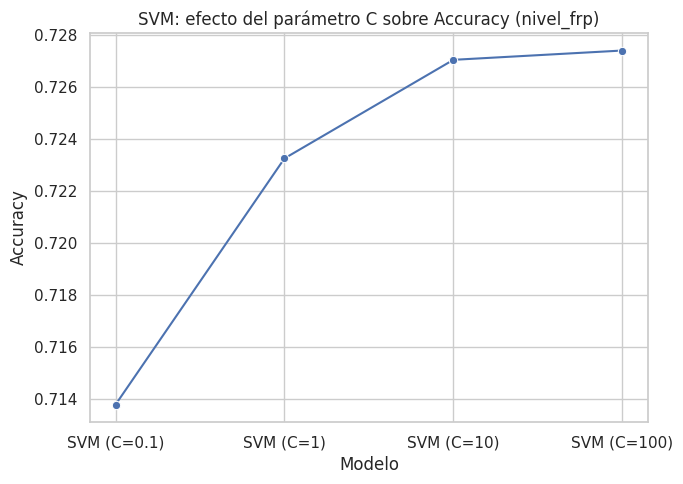

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC (macro OVR)
0,SVM (C=0.1),0.713780,0.735617,0.713780,0.718524,0.872021
1,SVM (C=1),0.723239,0.745226,0.723239,0.727501,0.879914
2,SVM (C=10),0.727028,0.747355,0.727028,0.730733,0.881737
3,SVM (C=100),0.727385,0.745376,0.727385,0.730832,0.880335


In [72]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np

RANDOM_STATE = 42

# Re-defining Xmc_train_small_s and ymc_train_small if previous cell (18f14139) was not run
# Assumes Xmc_train_s, ymc_train, np, and train_test_split are available in the kernel
SAMPLE_SIZE_MC = 30_000
idx_mc_sample, _ = train_test_split(
    np.arange(len(Xmc_train_s)), train_size=min(SAMPLE_SIZE_MC, len(Xmc_train_s)),
    random_state=RANDOM_STATE, stratify=ymc_train
)
Xmc_train_small_s = Xmc_train_s[idx_mc_sample]
ymc_train_small = ymc_train.iloc[idx_mc_sample]

resultados_svm_c_mc = []
for c_val in [0.1, 1, 10, 100]:
    m = SVC(kernel="rbf", C=c_val, gamma="scale", probability=True, random_state=RANDOM_STATE)
    m.fit(Xmc_train_small_s, ymc_train_small)
    pred = m.predict(Xmc_test_s)
    proba = m.predict_proba(Xmc_test_s)
    resultados_svm_c_mc.append(evaluate_classification_multiclass(ymc_test, pred, proba, f"SVM (C={c_val})"))

df_svm_c_mc = pd.DataFrame(resultados_svm_c_mc);

fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(data=df_svm_c_mc, x="Modelo", y="Accuracy", marker="o", ax=ax)
ax.set_title("SVM: efecto del parámetro C sobre Accuracy (nivel_frp)")
plt.tight_layout()
plt.show()

df_svm_c_mc

### C.8 Importancia de variables (modelos de árboles/boosting)

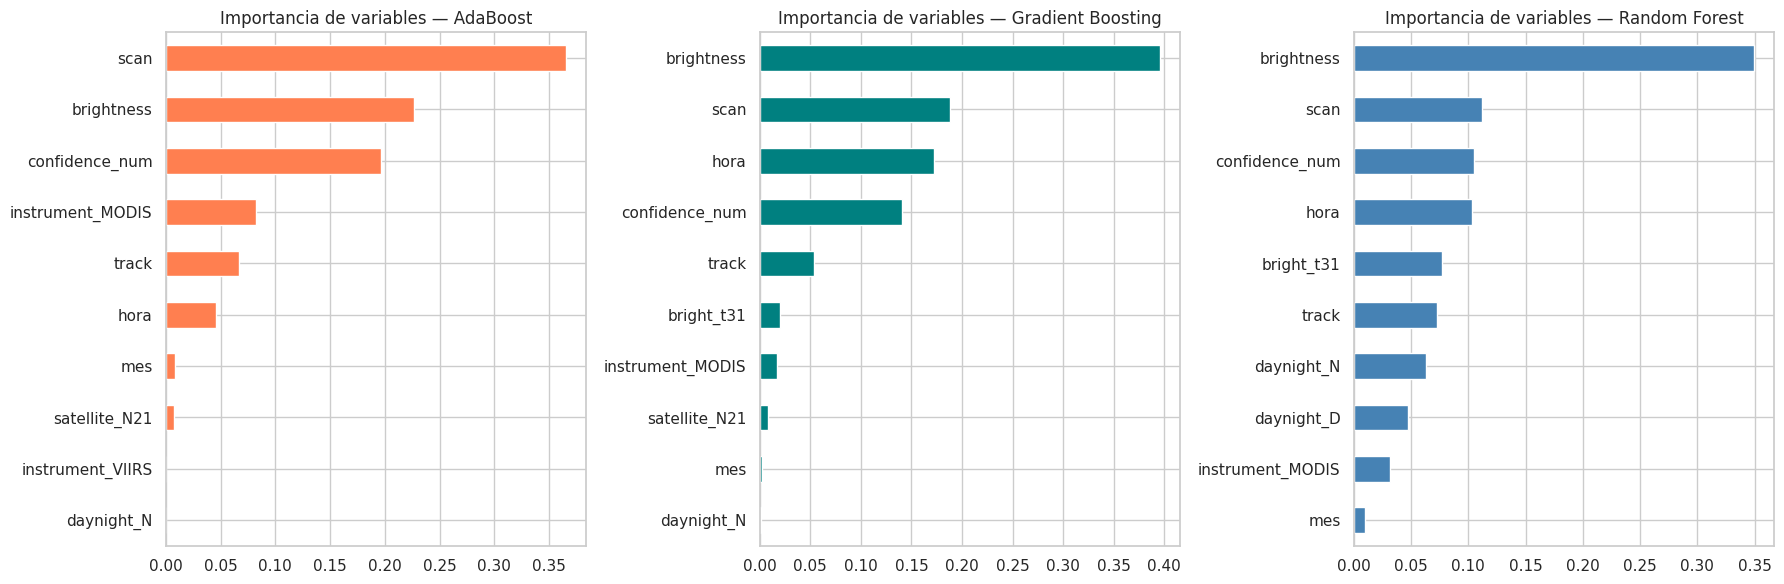

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (nombre, modelo, color) in zip(
    axes,
    [("AdaBoost", ada_mc, "coral"), ("Gradient Boosting", gb_mc, "teal"), ("Random Forest", rf_mc, "steelblue")]
):
    importancias = pd.Series(modelo.feature_importances_, index=X_mc.columns).sort_values()
    importancias.tail(10).plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Importancia de variables — {nombre}")
plt.tight_layout()
plt.show()


### C.9 Conclusión de la sección C (plantilla a completar)

- ¿Qué modelo tuvo mejor F1-Score/AUC en la tabla comparativa (C.4)?
- ¿Cómo se compara el desempeño de este enfoque (multiclase, `nivel_frp`) contra el de la Parte B (binario, `daynight_num`)? Ten en cuenta que son problemas distintos (3 clases vs 2 clases), así que no es una comparación directa de números, sino de qué tan bien cada variable objetivo separa a los datos.
- ¿Qué variable resultó más importante para distinguir los niveles de FRP? ¿Tiene sentido físico (por ejemplo, si `brightness` sigue dominando, o si ahora aparecen `mes`/`hora`/`satellite` con más peso)?
- ¿En qué categoría (Bajo/Medio/Alto) se equivocan más los modelos según las matrices de confusión? ¿Es un patrón esperable (ej. confundir clases adyacentes, Bajo↔Medio o Medio↔Alto, en vez de Bajo↔Alto)?


---
## Conclusión general del proyecto

Resume aquí, en 4-5 líneas:
1. Mejor modelo de regresión y por qué.
2. Mejor modelo de clasificación binaria (`daynight_num`) y por qué.
3. Mejor modelo de clasificación multiclase (`nivel_frp`) y por qué.
4. Ventajas/desventajas observadas de AdaBoost vs Gradient Boosting vs SVM en este dataset específico (600k registros de sensores satelitales), y cómo cambian (o no) esas conclusiones entre las tres tareas (regresión, clasificación binaria y multiclase).
5. Limitaciones (ej. SVM/KNN con muestra reducida, fuga de datos evitada al excluir frp/frp_log en la Parte C) y cómo se podrían superar con más recursos computacionales.


In [74]:
import joblib
import json
import os

os.makedirs("modelos_dashboard", exist_ok=True)

# --- Regresión (frp_log) ---
joblib.dump(lgbm_reg, "modelos_dashboard/reg_lightgbm.pkl")
joblib.dump(rf_reg, "modelos_dashboard/reg_random_forest.pkl")
joblib.dump(gb_reg, "modelos_dashboard/reg_gradient_boosting.pkl")
joblib.dump(ada_reg, "modelos_dashboard/reg_adaboost.pkl")
joblib.dump(svr, "modelos_dashboard/reg_svr.pkl")
joblib.dump(scaler_reg, "modelos_dashboard/scaler_regresion.pkl")

# --- Clasificación Día/Noche ---
joblib.dump(lgbm_clf, "modelos_dashboard/clf_daynight_lightgbm.pkl")
joblib.dump(rf_clf, "modelos_dashboard/clf_daynight_random_forest.pkl")
joblib.dump(ada_clf, "modelos_dashboard/clf_daynight_adaboost.pkl")
joblib.dump(gb_clf, "modelos_dashboard/clf_daynight_gradient_boosting.pkl")
joblib.dump(svm_clf, "modelos_dashboard/clf_daynight_svm.pkl")
joblib.dump(scaler_clf, "modelos_dashboard/scaler_daynight.pkl")

# --- Clasificación nivel_frp ---
joblib.dump(lgbm_mc, "modelos_dashboard/clf_nivel_lightgbm.pkl")
joblib.dump(rf_mc, "modelos_dashboard/clf_nivel_random_forest.pkl")
joblib.dump(ada_mc, "modelos_dashboard/clf_nivel_adaboost.pkl")
joblib.dump(gb_mc, "modelos_dashboard/clf_nivel_gradient_boosting.pkl")
joblib.dump(svm_mc, "modelos_dashboard/clf_nivel_svm.pkl")
joblib.dump(scaler_mc, "modelos_dashboard/scaler_nivel.pkl")

# --- Tablas de métricas (para la página de comparación) ---
df_resultados_reg.to_json("modelos_dashboard/metricas_regresion.json", orient="records")
df_resultados_clf.to_json("modelos_dashboard/metricas_daynight.json", orient="records")
df_resultados_mc.to_json("modelos_dashboard/metricas_nivel.json", orient="records")

print("Modelos y métricas exportados en la carpeta 'modelos_dashboard/'")

Modelos y métricas exportados en la carpeta 'modelos_dashboard/'
